# Notebook 3 — Spectral Analysis

The sheaf Laplacian $L_F[\Omega, \Omega]$ depends on the input $x$ through
the ReLU activation masks. Its spectral properties reveal the geometry of
the learning dynamics:

- **Spectral gap** ($\lambda_1$): smallest non-zero eigenvalue, controls
  the rate of diffusion convergence.
- **Largest eigenvalue** ($\lambda_{\max}$): governs the stiffness of the system.
- **Condition number** ($\kappa = \lambda_{\max} / \lambda_1$): measures how
  uniformly information propagates through the network.
- **Eigenvector structure**: shows which layers and neurons dominate the
  slowest and fastest diffusion modes.

We train both the sheaf method and standard SGD once, capture model snapshots
at three training levels (poorly trained, intermediate, well trained), and
compute the full spectral analysis at each stage. Hyperparameters match those
validated in Notebook 2 ($\beta = 1/n$, $dt = 0.005$).

---
## 1. Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from neural_sheaf.sheaf import NeuralSheaf
from neural_sheaf.tasks import (
    TASK_CONFIGS,
    compute_levels,
    train_sheaf_full,
    train_sgd_full,
)
from neural_sheaf.spectral import spectral_analysis_per_sample
from neural_sheaf.visualization import (
    plot_eigenvalue_spectra,
    plot_spectral_gap_dist,
    plot_spectral_gap_training,
    plot_loss_spectral_dual,
    plot_condition_number_dist,
    plot_spectral_tracking_extended,
    plot_eigenvector_layer_energy_row,
    plot_stability_overlay,
    plot_neuron_contributions,
    plot_loss_spectral_dual_extended,
)

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
})

### Configuration

In [2]:
TASK = 'paraboloid'          # 'paraboloid', 'saddle', 'circular', 'blobs'
N_SPECTRAL_SAMPLES = 50      # Samples for per-level spectral analysis
N_DIST_SAMPLES = 100         # Samples for distribution histograms
SPECTRAL_FREQ = 10_000       # Record spectral snapshot every N steps
SEED_WEIGHTS = 0
SEED_STALKS = 42

# Resolve task config (hyperparameters match Notebook 2)
cfg = TASK_CONFIGS[TASK]
arch = cfg['default_arch']
n_steps = cfg['default_n_steps']
dt = cfg['default_dt']
n_train = cfg['n_train']
beta = 1.0 / n_train              # β = 1/n, as in Notebook 2
output_activation = cfg['output_activation']
sgd_lr = cfg['sgd_lr']
init_method = cfg.get('init_method', 'random')

print(f"Task: {TASK}")
print(f"Architecture: {arch}")
print(f"β = 1/{n_train} = {beta:.6f}, dt = {dt}")
print(f"SGD lr = {sgd_lr}, n_steps = {n_steps}")


Task: paraboloid
Architecture: [2, 30, 1]
β = 1/300 = 0.003333, dt = 0.005
SGD lr = 0.005, n_steps = 100000


In [3]:
# Data
X_tr, Y_tr, X_te, Y_te = cfg['data_fn']()
X_sub = X_tr[:, :N_SPECTRAL_SAMPLES]
X_dist = X_tr[:, :min(N_DIST_SAMPLES, X_tr.shape[1])]

# Training levels
levels, level_tags = compute_levels(n_steps)
snapshot_steps = [s for _, s, _ in levels]
level_labels = [f"{l} ({t})" for (l, _, _), t in zip(levels, level_tags)]
level_colors = [c for _, _, c in levels]

print(f"Data: X_tr {X_tr.shape}, Y_tr {Y_tr.shape}")
print(f"Levels: {list(zip(level_labels, snapshot_steps))}")

Data: X_tr torch.Size([2, 300]), Y_tr torch.Size([1, 300])
Levels: [('Poorly trained (1k)', 1000), ('Intermediate (20k)', 20000), ('Well trained (100k)', 100000)]


---
## 2. Train Both Methods

We train each method once for the full `n_steps`, capturing model snapshots
at each training level and periodic spectral statistics.

In [4]:
print("Training sheaf (with spectral tracking)...")
sheaf_history, sheaf_snapshots = train_sheaf_full(
    arch, X_tr, Y_tr, X_te, Y_te, n_steps, beta, dt,
    output_activation, snapshot_steps, SPECTRAL_FREQ, X_sub,
    seed_w=SEED_WEIGHTS, seed_s=SEED_STALKS,
    init_method=init_method)

print("\nTraining SGD (with spectral tracking)...")
sgd_history, sgd_snapshots = train_sgd_full(
    arch, X_tr, Y_tr, X_te, Y_te, n_steps,
    output_activation, sgd_lr, snapshot_steps, SPECTRAL_FREQ, X_sub,
    seed=SEED_WEIGHTS)


Training sheaf (with spectral tracking)...
  Step     0 | loss=12.099576  λ₁=0.1911  λ_max=3.58  κ=18.7
  Step  10000 | loss=0.529305  λ₁=0.0511  λ_max=12.75  κ=249.5
  Step  20000 | loss=0.231004  λ₁=0.0415  λ_max=15.64  κ=376.8
  Step  30000 | loss=0.134055  λ₁=0.0378  λ_max=17.22  κ=455.5
  Step  40000 | loss=0.098778  λ₁=0.0359  λ_max=18.19  κ=506.9
  Step  50000 | loss=0.084129  λ₁=0.0346  λ_max=18.84  κ=543.9
  Step  60000 | loss=0.076696  λ₁=0.0338  λ_max=19.31  κ=570.7
  Step  70000 | loss=0.071971  λ₁=0.0332  λ_max=19.68  κ=592.3
  Step  80000 | loss=0.068423  λ₁=0.0327  λ_max=19.98  κ=610.5
  Step  90000 | loss=0.065534  λ₁=0.0323  λ_max=20.24  κ=626.3
  Step 100000 | loss=0.063092  λ₁=0.0324  λ_max=20.47  κ=631.8

Training SGD (with spectral tracking)...
  Step     0 | loss=12.099576  λ₁=0.1911  λ_max=3.58  κ=18.7
  Step  10000 | loss=0.029372  λ₁=0.0934  λ_max=7.80  κ=83.6
  Step  20000 | loss=0.008678  λ₁=0.0731  λ_max=10.43  κ=142.8
  Step  30000 | loss=0.005797  λ₁=0.067

In [5]:
# Map tag -> (sheaf, state, loss) for each method
sheaf_models = {tag: sheaf_snapshots[s]
                for (_, s, _), tag in zip(levels, level_tags)}
sgd_models = {tag: sgd_snapshots[s]
              for (_, s, _), tag in zip(levels, level_tags)}

# Extract NeuralSheaf objects for spectral analysis
sheaf_spectral = {tag: sheaf_snapshots[s][0]
                  for (_, s, _), tag in zip(levels, level_tags)}
sgd_spectral = {tag: sgd_snapshots[s][0]
                for (_, s, _), tag in zip(levels, level_tags)}

---
## 3. Spectral Analysis at Training Levels

For each training level we compute the full spectral decomposition of
$L_F[\Omega, \Omega]$. Because the Laplacian depends on the input
through the ReLU masks, each input sample yields a different spectrum.

In [6]:
print("Computing spectral analysis at each level...")
sheaf_analyses = {}     # tag -> result on X_sub
sgd_analyses = {}
sheaf_dist = {}         # tag -> result on X_dist
sgd_dist = {}

for (label, _, _), tag in zip(levels, level_tags):
    full = f"{label} ({tag})"

    r = spectral_analysis_per_sample(sheaf_spectral[tag], X_sub)
    sheaf_analyses[tag] = r
    sheaf_dist[tag] = spectral_analysis_per_sample(sheaf_spectral[tag], X_dist)
    print(f"  Sheaf {full}: "
          f"λ₁={np.median(r['gaps']):.4f}  "
          f"λ_max={np.median(r['lambda_max']):.2f}  "
          f"κ={np.median(r['condition_numbers']):.1f}")

    r = spectral_analysis_per_sample(sgd_spectral[tag], X_sub)
    sgd_analyses[tag] = r
    sgd_dist[tag] = spectral_analysis_per_sample(sgd_spectral[tag], X_dist)
    print(f"  SGD   {full}: "
          f"λ₁={np.median(r['gaps']):.4f}  "
          f"λ_max={np.median(r['lambda_max']):.2f}  "
          f"κ={np.median(r['condition_numbers']):.1f}")

tags = list(sheaf_analyses.keys())
best_tag = level_tags[-1]

Computing spectral analysis at each level...
  Sheaf Poorly trained (1k): λ₁=0.1126  λ_max=5.90  κ=52.4
  SGD   Poorly trained (1k): λ₁=0.1337  λ_max=5.18  κ=38.7
  Sheaf Intermediate (20k): λ₁=0.0415  λ_max=15.64  κ=376.8
  SGD   Intermediate (20k): λ₁=0.0731  λ_max=10.43  κ=142.8
  Sheaf Well trained (100k): λ₁=0.0324  λ_max=20.47  κ=631.8
  SGD   Well trained (100k): λ₁=0.0610  λ_max=12.79  κ=209.5


### 3a. Eigenvalue Spectra

Sorted eigenvalue distributions at each training level.

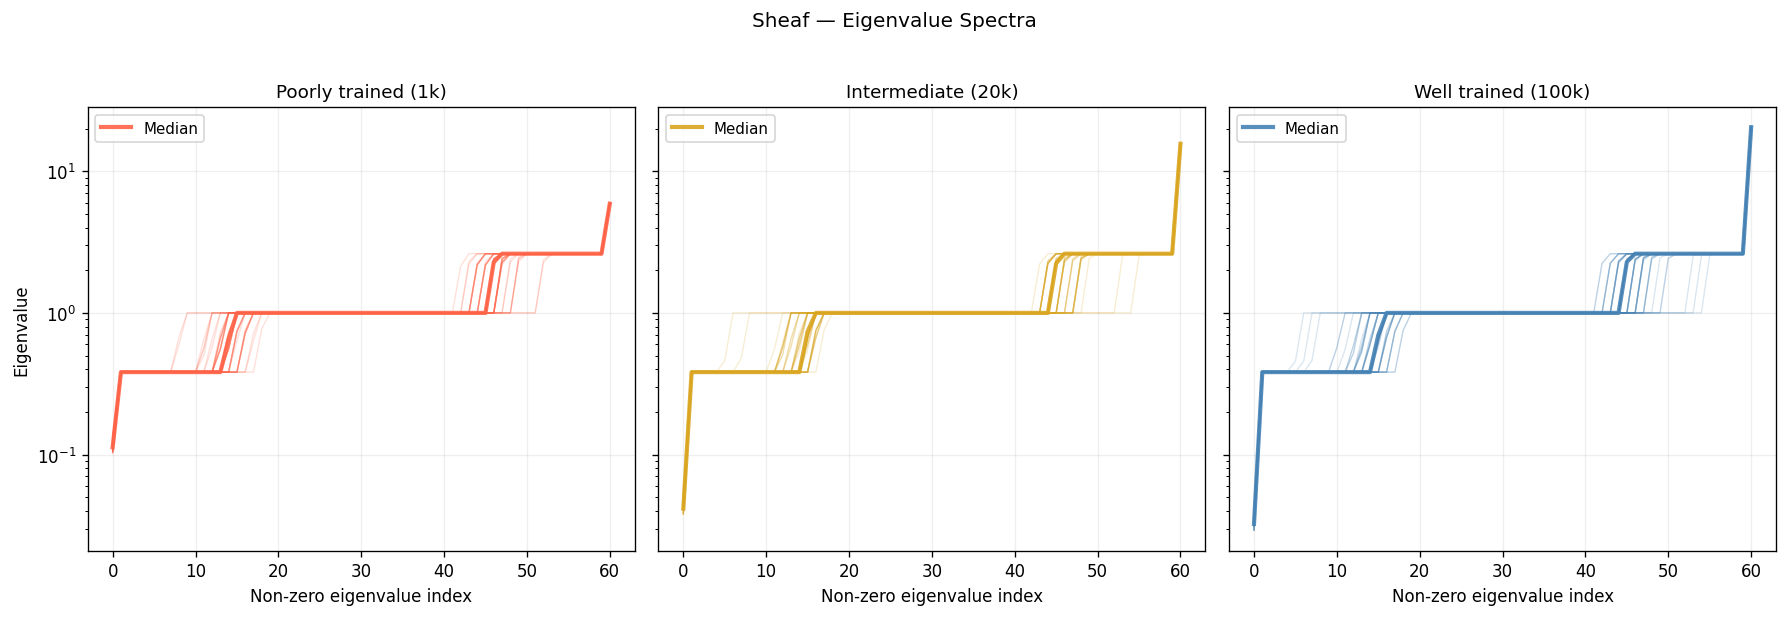

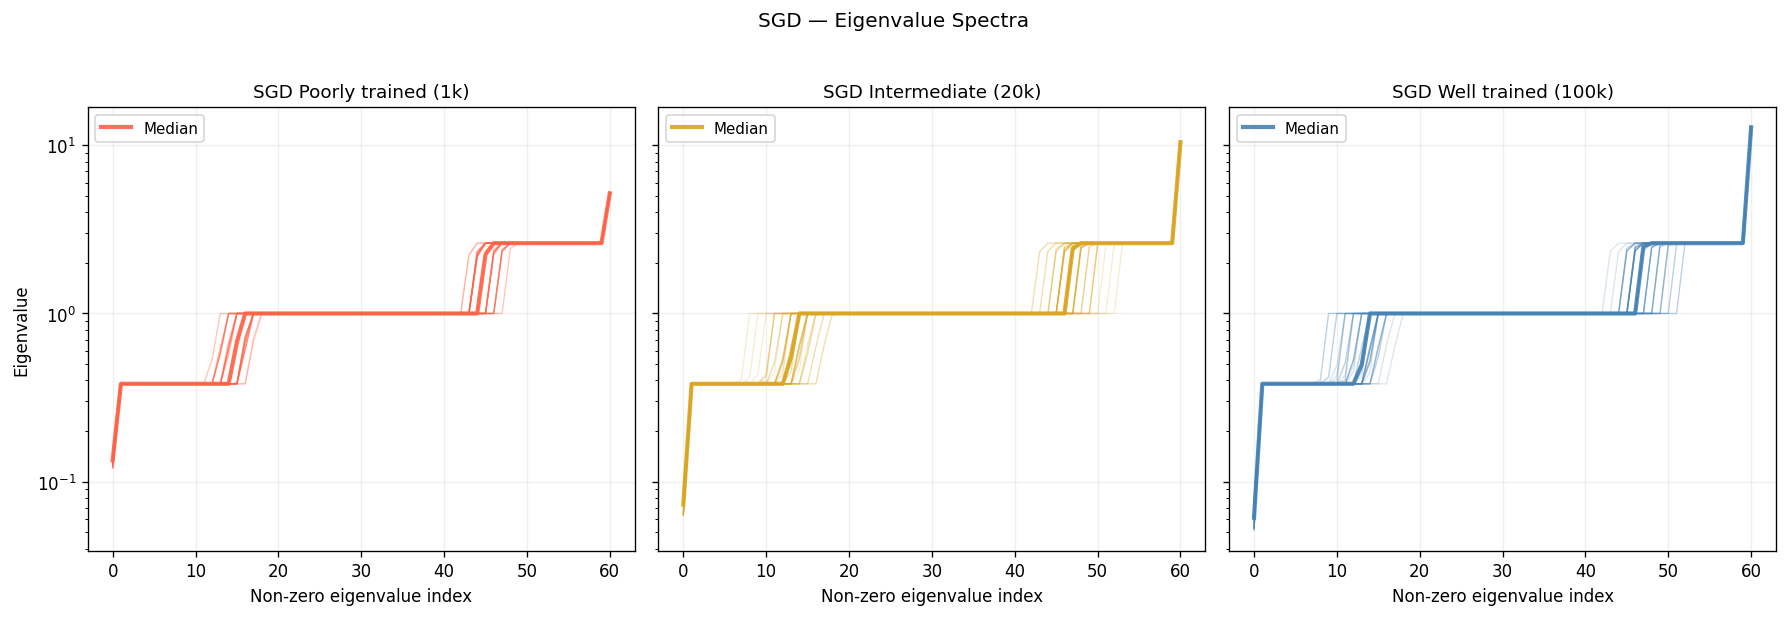

In [7]:
fig_sheaf_spectra = plot_eigenvalue_spectra(
    [sheaf_analyses[t]['eigenvalues'] for t in tags],
    level_labels, level_colors)
fig_sheaf_spectra.suptitle('Sheaf — Eigenvalue Spectra', y=1.02)
plt.show()

fig_sgd_spectra = plot_eigenvalue_spectra(
    [sgd_analyses[t]['eigenvalues'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors)
fig_sgd_spectra.suptitle('SGD — Eigenvalue Spectra', y=1.02)
plt.show()

### 3b. Spectral Gap Distributions

Histograms of $\lambda_1$ across input samples. All three training levels
overlaid on one plot per method, with shared x-axes for sheaf vs SGD.

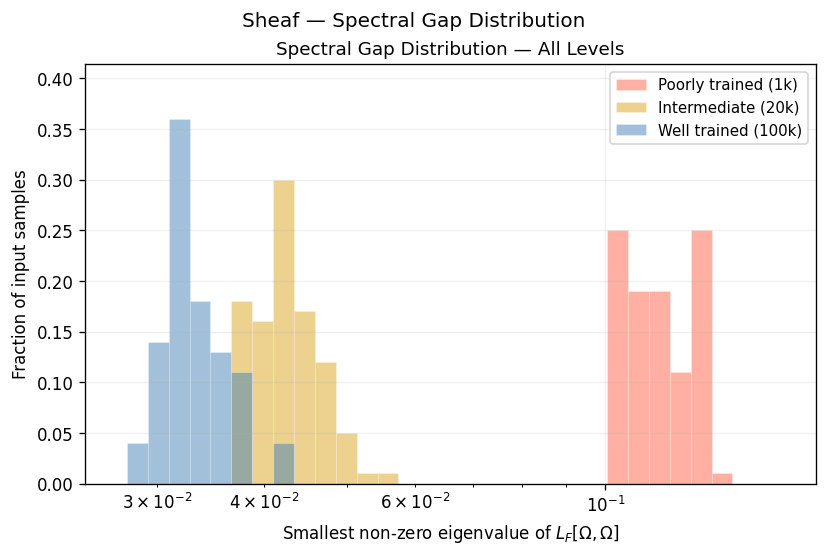

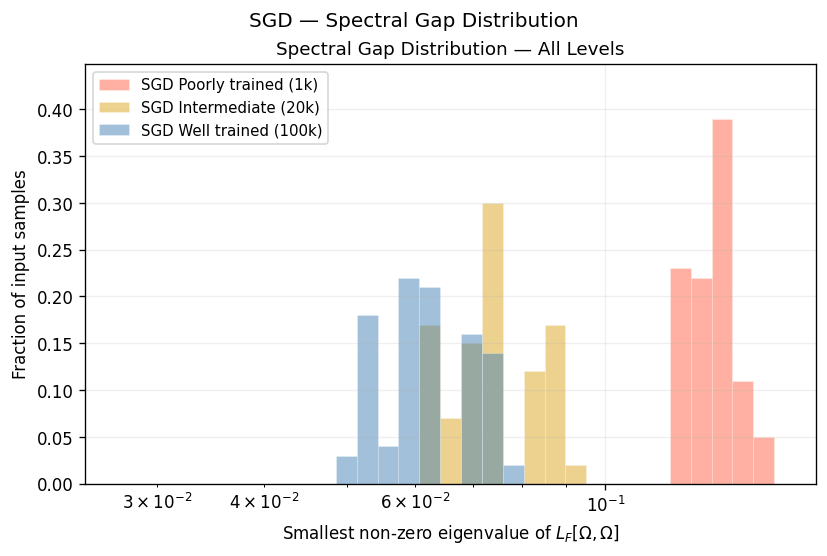

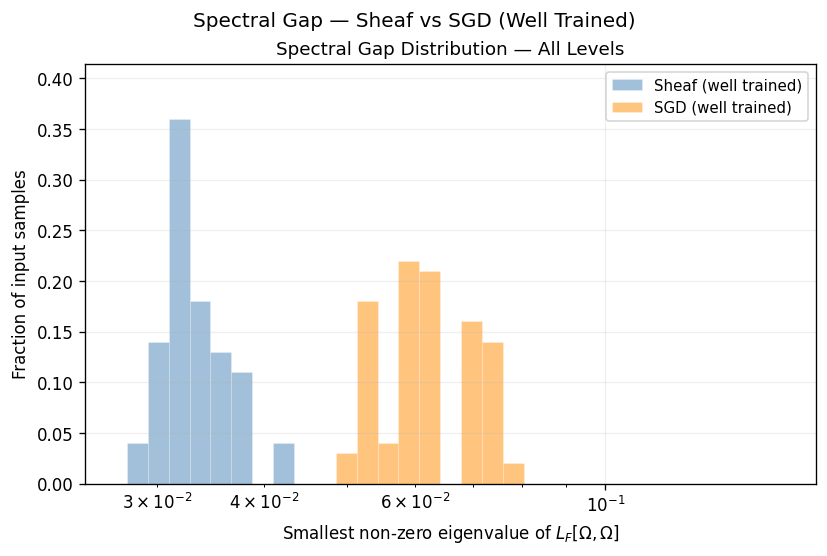

In [8]:
# Compute shared x-axis range from both methods
all_gaps = np.concatenate(
    [sheaf_dist[t]['gaps'] for t in tags]
    + [sgd_dist[t]['gaps'] for t in tags])
gap_range = (all_gaps[all_gaps > 0].min() * 0.85, all_gaps.max() * 1.15)

# Sheaf: all three levels overlaid
fig_c, figs_i = plot_spectral_gap_dist(
    [sheaf_dist[t]['gaps'] for t in tags], level_labels, level_colors,
    data_range=gap_range)
fig_c.suptitle('Sheaf — Spectral Gap Distribution', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

# SGD: all three levels overlaid
fig_c, figs_i = plot_spectral_gap_dist(
    [sgd_dist[t]['gaps'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors,
    data_range=gap_range)
fig_c.suptitle('SGD — Spectral Gap Distribution', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

# Well-trained: sheaf vs SGD on shared axes
fig_c, figs_i = plot_spectral_gap_dist(
    [sheaf_dist[best_tag]['gaps'], sgd_dist[best_tag]['gaps']],
    ['Sheaf (well trained)', 'SGD (well trained)'],
    ['steelblue', 'darkorange'],
    data_range=gap_range)
fig_c.suptitle('Spectral Gap — Sheaf vs SGD (Well Trained)', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

### 3c. $\lambda_{\max}$ Distributions

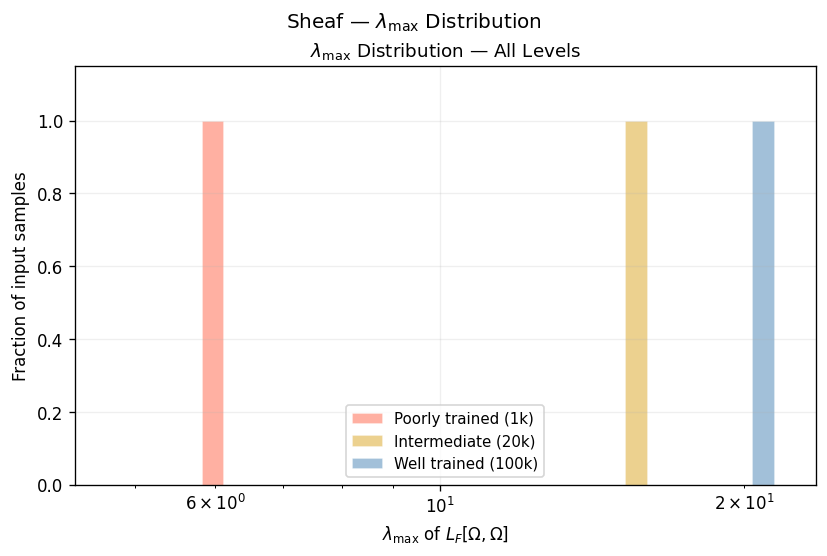

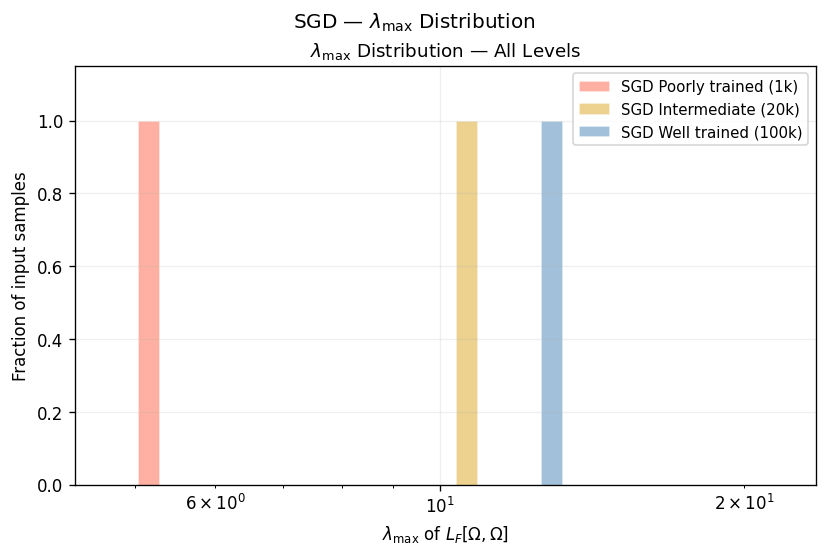

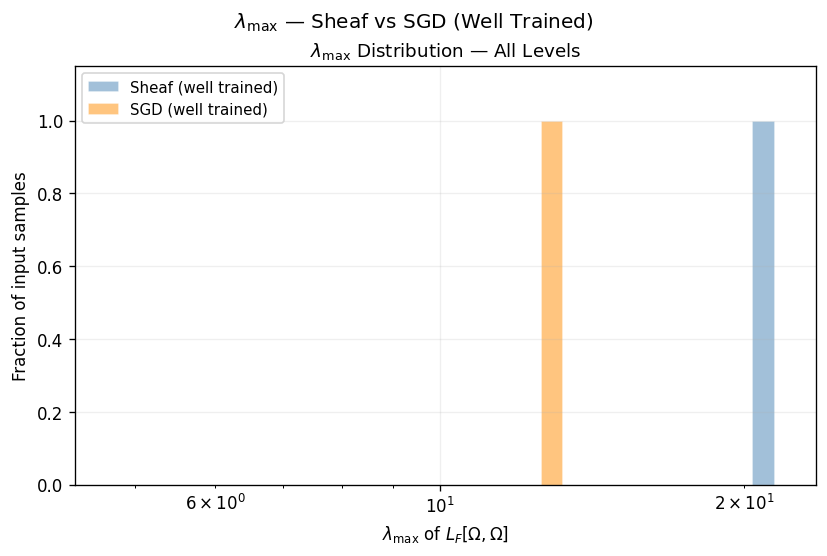

In [9]:
# Shared x-axis range for lambda_max
all_lmax = np.concatenate(
    [sheaf_dist[t]['lambda_max'] for t in tags]
    + [sgd_dist[t]['lambda_max'] for t in tags])
lmax_range = (all_lmax[all_lmax > 0].min() * 0.85, all_lmax.max() * 1.15)

# Sheaf: all three levels
fig_c, figs_i = plot_spectral_gap_dist(
    [sheaf_dist[t]['lambda_max'] for t in tags], level_labels, level_colors,
    xlabel=r'$\lambda_{\max}$ of $L_F[\Omega,\Omega]$',
    dist_label=r'$\lambda_{\max}$',
    data_range=lmax_range)
fig_c.suptitle(r'Sheaf — $\lambda_{\max}$ Distribution', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

# SGD: all three levels
fig_c, figs_i = plot_spectral_gap_dist(
    [sgd_dist[t]['lambda_max'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors,
    xlabel=r'$\lambda_{\max}$ of $L_F[\Omega,\Omega]$',
    dist_label=r'$\lambda_{\max}$',
    data_range=lmax_range)
fig_c.suptitle(r'SGD — $\lambda_{\max}$ Distribution', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

# Well-trained: sheaf vs SGD
fig_c, figs_i = plot_spectral_gap_dist(
    [sheaf_dist[best_tag]['lambda_max'], sgd_dist[best_tag]['lambda_max']],
    ['Sheaf (well trained)', 'SGD (well trained)'],
    ['steelblue', 'darkorange'],
    xlabel=r'$\lambda_{\max}$ of $L_F[\Omega,\Omega]$',
    dist_label=r'$\lambda_{\max}$',
    data_range=lmax_range)
fig_c.suptitle(r'$\lambda_{\max}$ — Sheaf vs SGD (Well Trained)', y=1.02)
for f in figs_i: plt.close(f)
plt.show()

### 3d. Condition Number Distributions

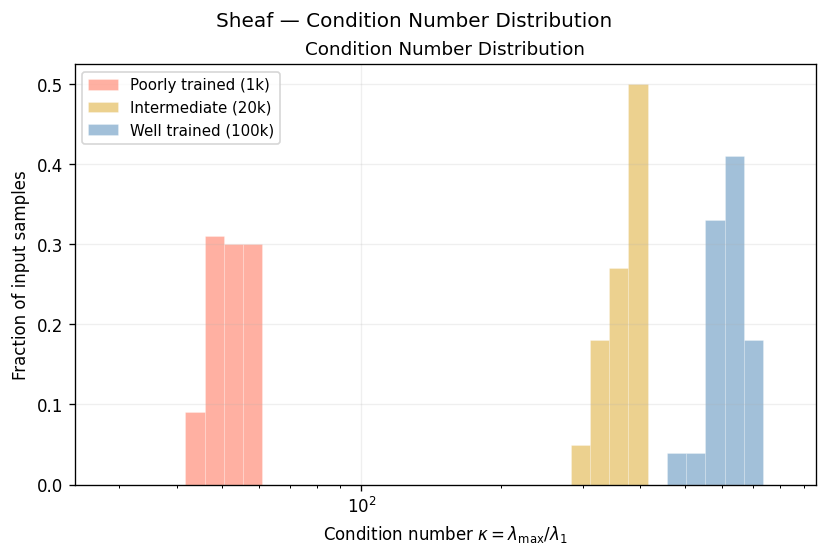

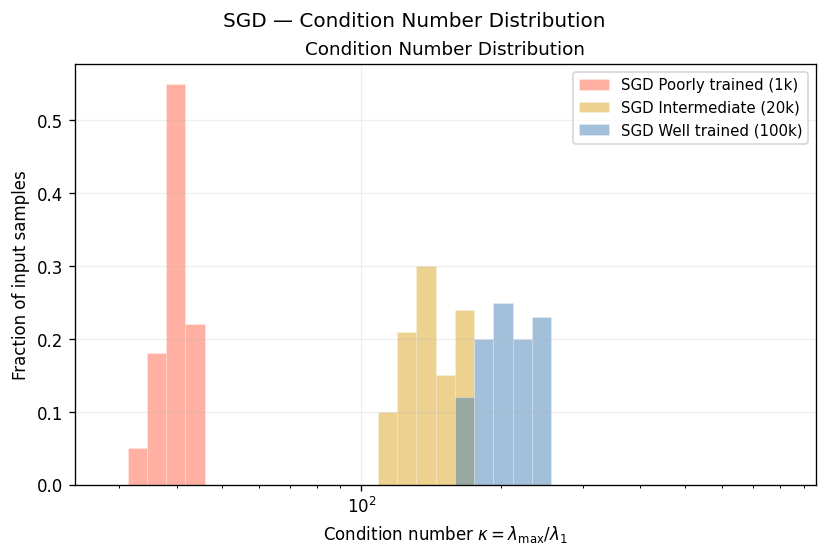

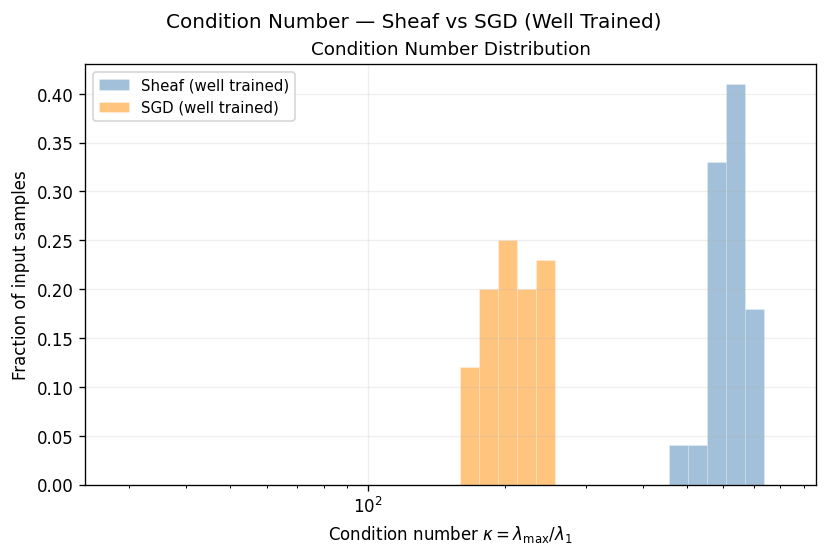

In [10]:
# Shared x-axis range for condition numbers
all_kappa = np.concatenate(
    [sheaf_dist[t]['condition_numbers'] for t in tags]
    + [sgd_dist[t]['condition_numbers'] for t in tags])
finite_kappa = all_kappa[np.isfinite(all_kappa)]
kappa_range = (finite_kappa.min() * 0.85, finite_kappa.max() * 1.15)

fig = plot_condition_number_dist(
    [sheaf_dist[t]['condition_numbers'] for t in tags],
    level_labels, level_colors, data_range=kappa_range)
fig.suptitle('Sheaf — Condition Number Distribution', y=1.02)
plt.show()

fig = plot_condition_number_dist(
    [sgd_dist[t]['condition_numbers'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors, data_range=kappa_range)
fig.suptitle('SGD — Condition Number Distribution', y=1.02)
plt.show()

# Well-trained: sheaf vs SGD
fig = plot_condition_number_dist(
    [sheaf_dist[best_tag]['condition_numbers'],
     sgd_dist[best_tag]['condition_numbers']],
    ['Sheaf (well trained)', 'SGD (well trained)'],
    ['steelblue', 'darkorange'], data_range=kappa_range)
fig.suptitle('Condition Number — Sheaf vs SGD (Well Trained)', y=1.02)
plt.show()

---
## 4. Eigenvector Structure

The Fiedler vector (eigenvector of $\lambda_1$) and the $\lambda_{\max}$
eigenvector reveal which layers and neurons dominate the slowest and
fastest diffusion modes.

### 4a. Layer Energy Decomposition

For each eigenvector, we decompose the squared norm across the free
stalk blocks ($z_1, a_1, z_2, a_2, \ldots, z_{k+1}$). Each row shows
all three training levels side by side for direct comparison.

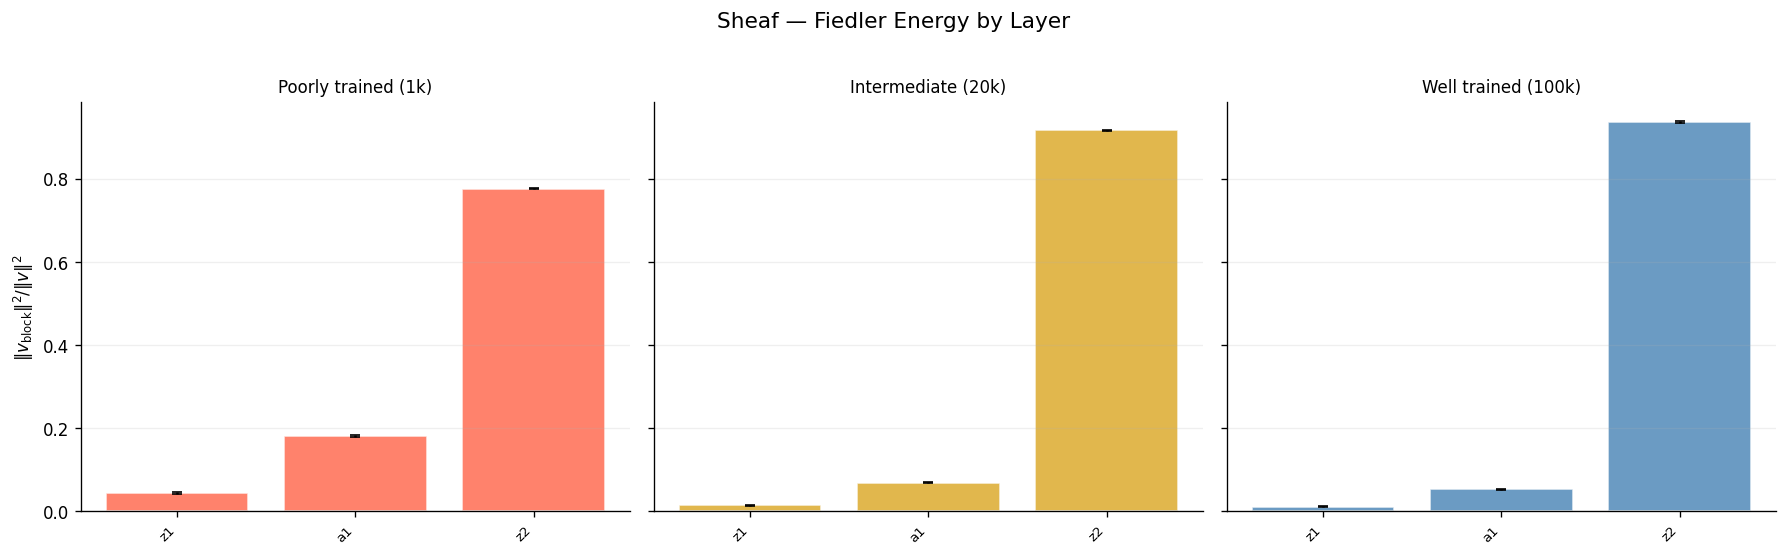

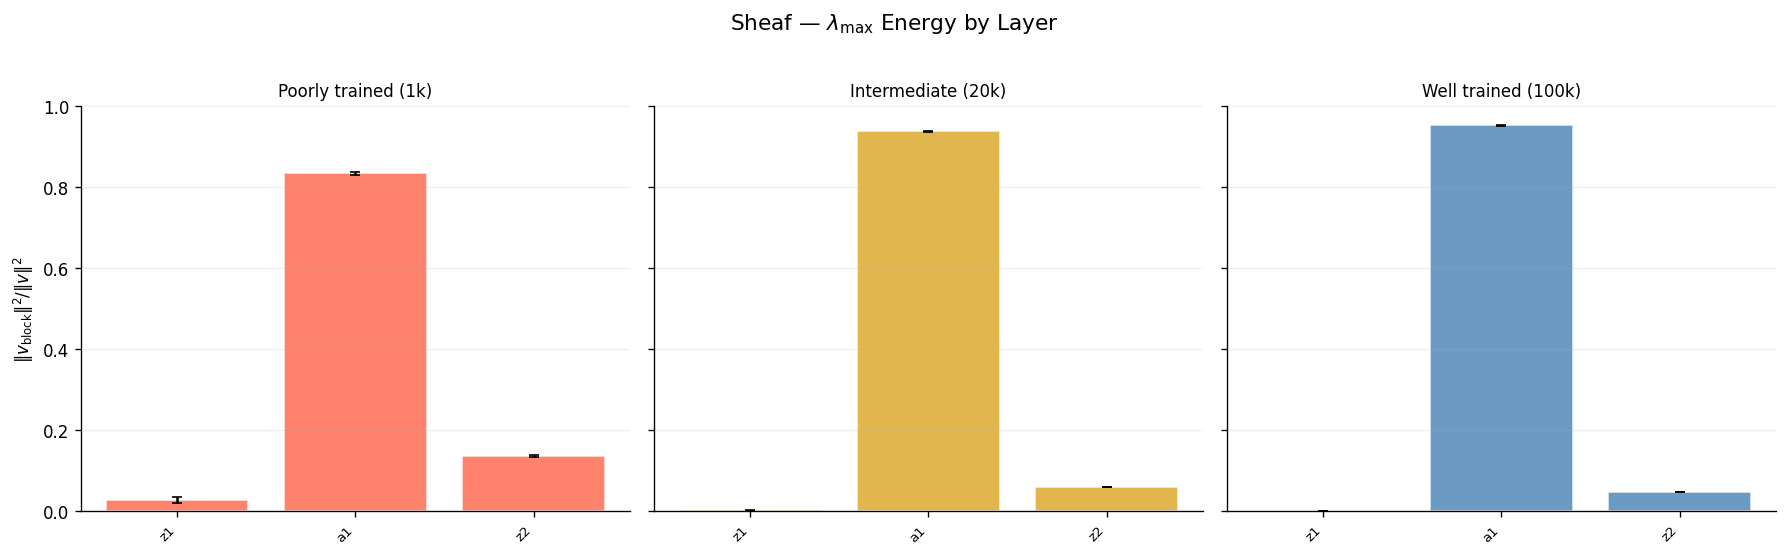

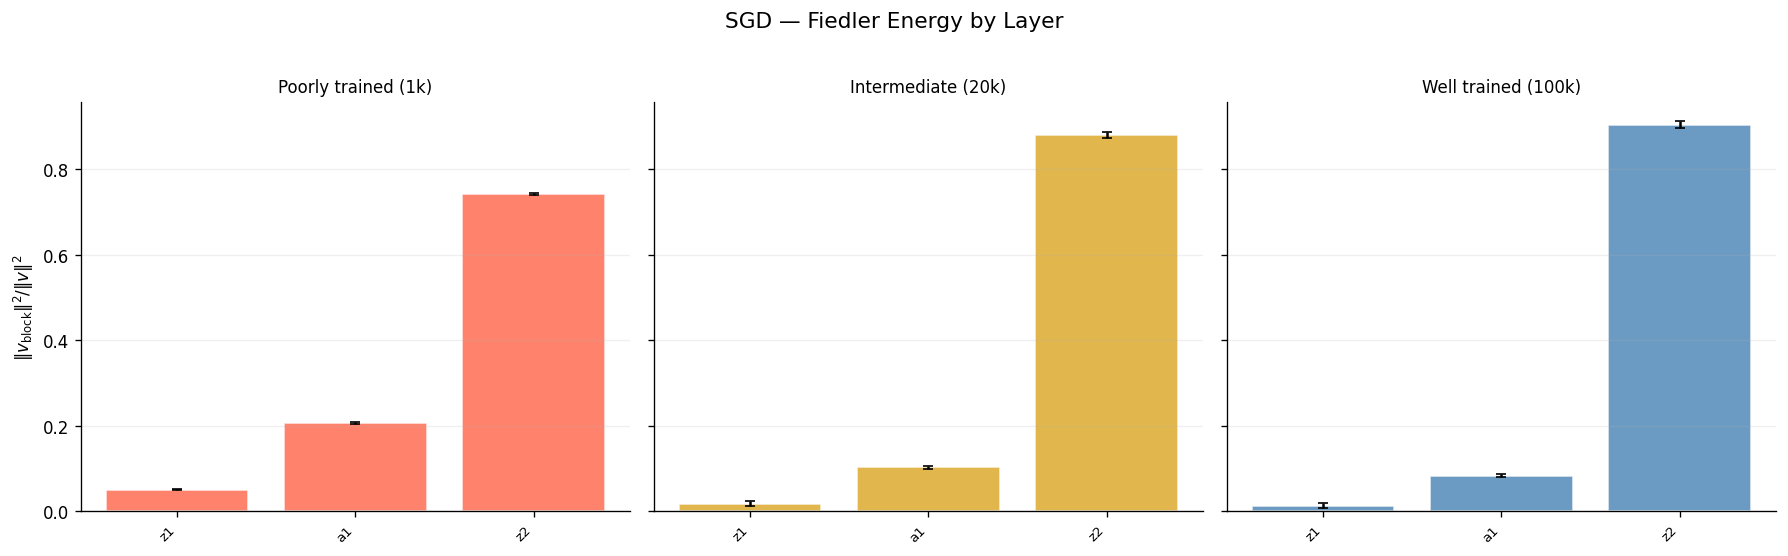

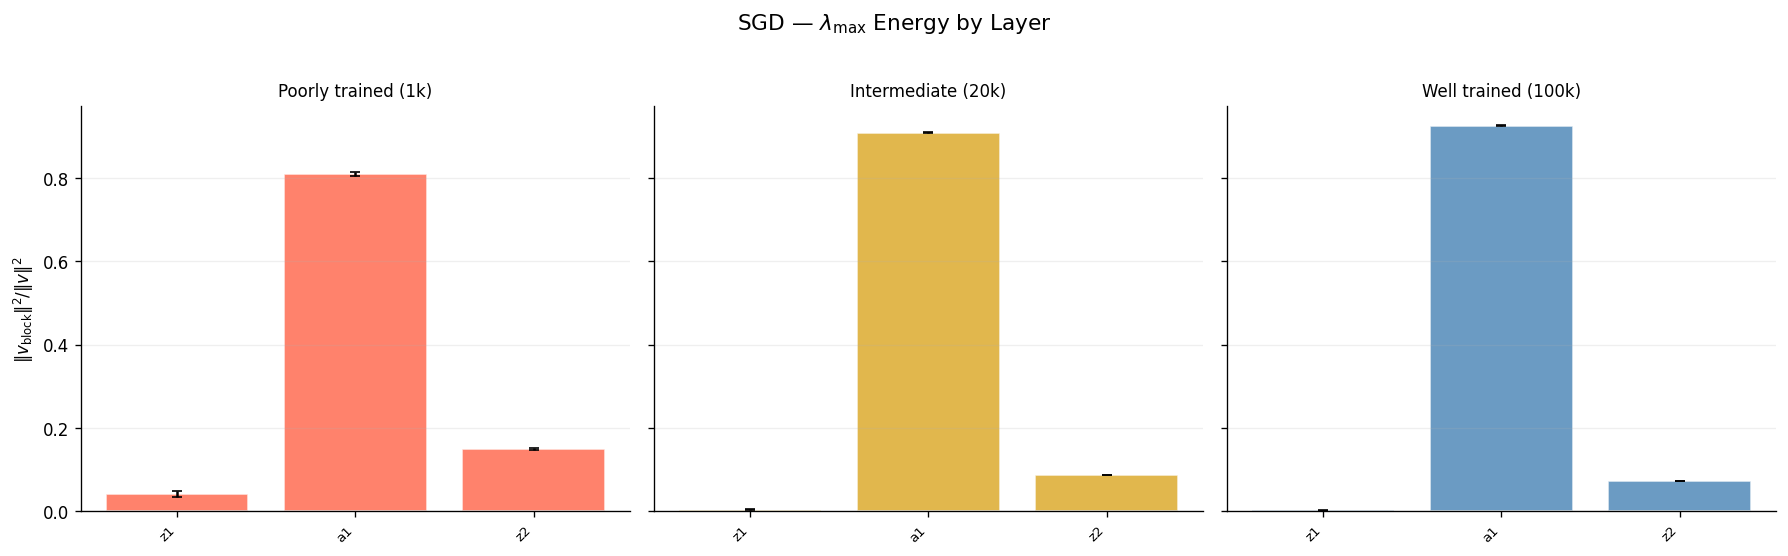

In [ ]:
# Block ranges are the same across levels (same architecture)
block_ranges = sheaf_analyses[tags[0]]['block_ranges']

for method_name, analyses in [('Sheaf', sheaf_analyses), ('SGD', sgd_analyses)]:
    # Fiedler: one row across levels
    fig = plot_eigenvector_layer_energy_row(
        [analyses[t]['fiedler_layer_energy'] for t in tags],
        block_ranges, level_labels, level_colors,
        suptitle=f'{method_name} — Fiedler Energy by Layer')
    plt.show()

    # lambda_max: one row across levels
    fig = plot_eigenvector_layer_energy_row(
        [analyses[t]['max_layer_energy'] for t in tags],
        block_ranges, level_labels, level_colors,
        suptitle=rf'{method_name} — $\lambda_{{\max}}$ Energy by Layer')
    plt.show()

### 4b. Neuron Contributions

Per-neuron breakdown within the dominant block (the block carrying the
most Fiedler energy). For single-neuron blocks (e.g. the output layer),
the value is printed rather than plotted.

  Sheaf Poorly trained (1k) — Fiedler — z2: |v|² = 0.7760 ± 0.0016 (single neuron)


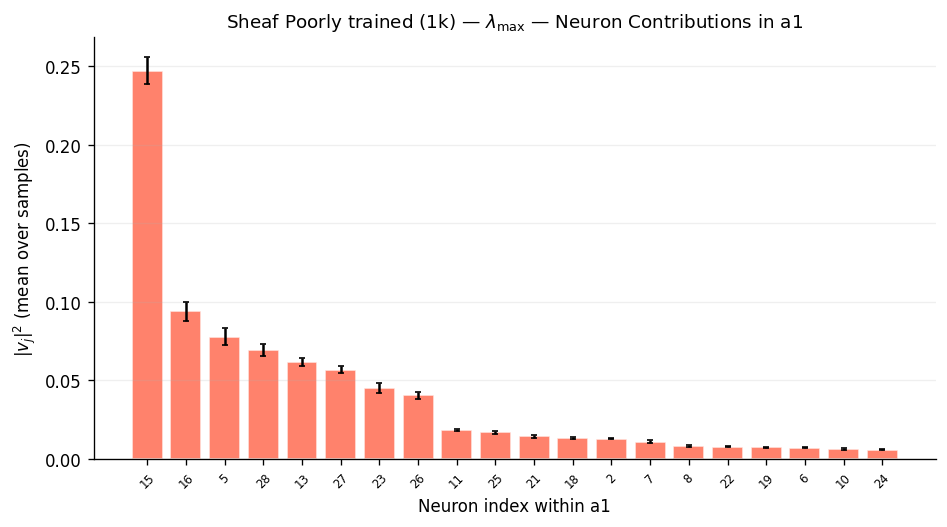

  Sheaf Intermediate (20k) — Fiedler — z2: |v|² = 0.9164 ± 0.0013 (single neuron)


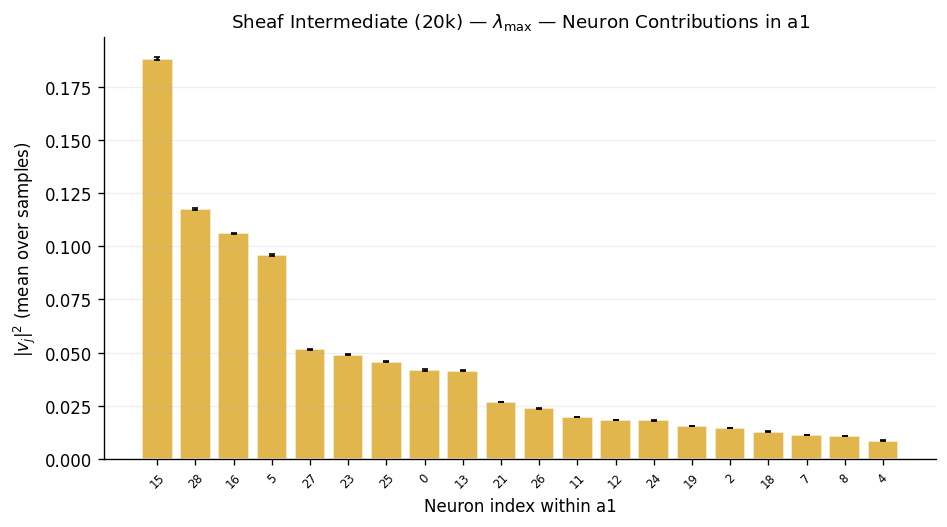

  Sheaf Well trained (100k) — Fiedler — z2: |v|² = 0.9361 ± 0.0013 (single neuron)


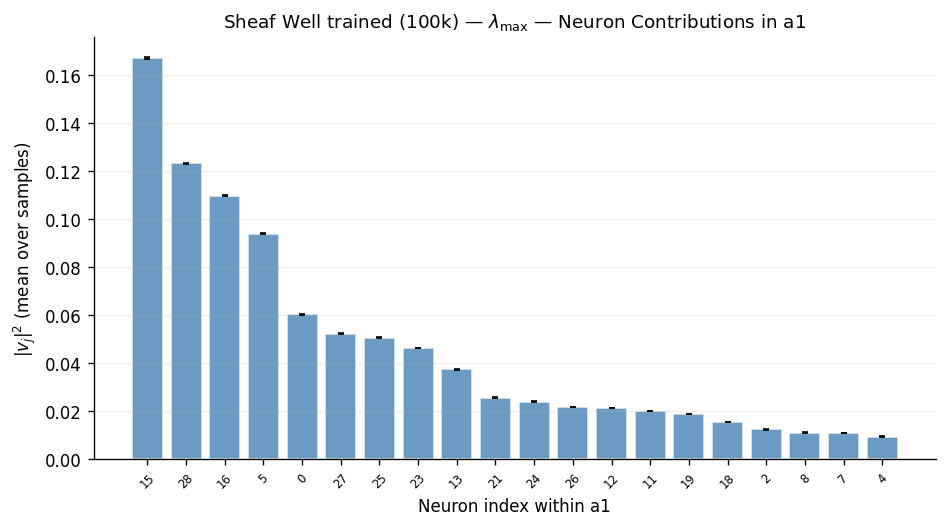

  SGD Poorly trained (1k) — Fiedler — z2: |v|² = 0.7423 ± 0.0016 (single neuron)


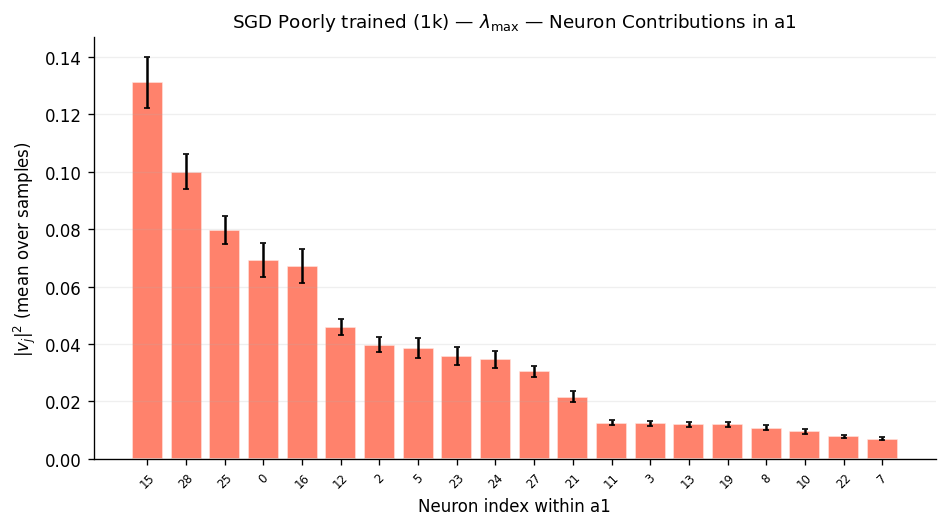

  SGD Intermediate (20k) — Fiedler — z2: |v|² = 0.8795 ± 0.0077 (single neuron)


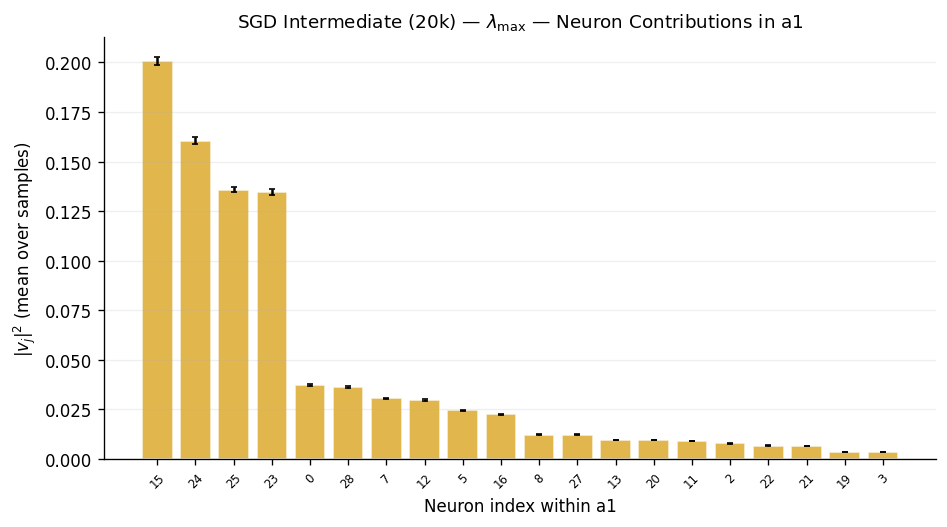

  SGD Well trained (100k) — Fiedler — z2: |v|² = 0.9035 ± 0.0081 (single neuron)


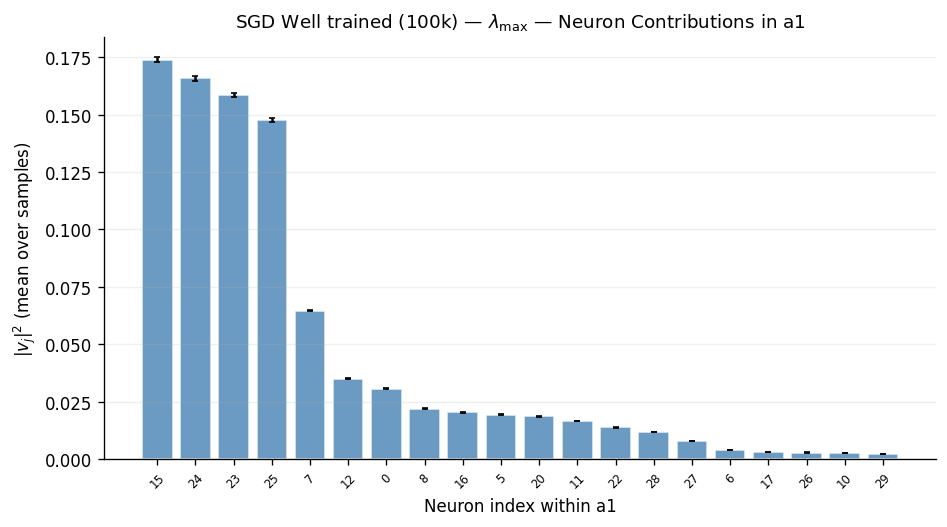

In [12]:
for method_name, analyses in [('Sheaf', sheaf_analyses), ('SGD', sgd_analyses)]:
    for (label, _, _), tag, color in zip(levels, level_tags, level_colors):
        full = f"{method_name} {label} ({tag})"
        result = analyses[tag]

        fig_fn = plot_neuron_contributions(
            result['fiedler_neuron_contributions'],
            eigvec_label='Fiedler', color=color,
            title=f'{full} — ')
        if fig_fn is not None:
            plt.show()

        fig_mn = plot_neuron_contributions(
            result['max_neuron_contributions'],
            eigvec_label=r'$\lambda_{\max}$', color=color,
            title=f'{full} — ')
        if fig_mn is not None:
            plt.show()

### 4c. Eigenvector Stability

How consistent are the eigenvector directions across input samples?
High stability (mean $|\cos\theta|$ close to 1) means the mode structure
is input-independent. We show all three training levels on a single
plot for each method, then compare well-trained sheaf vs SGD.

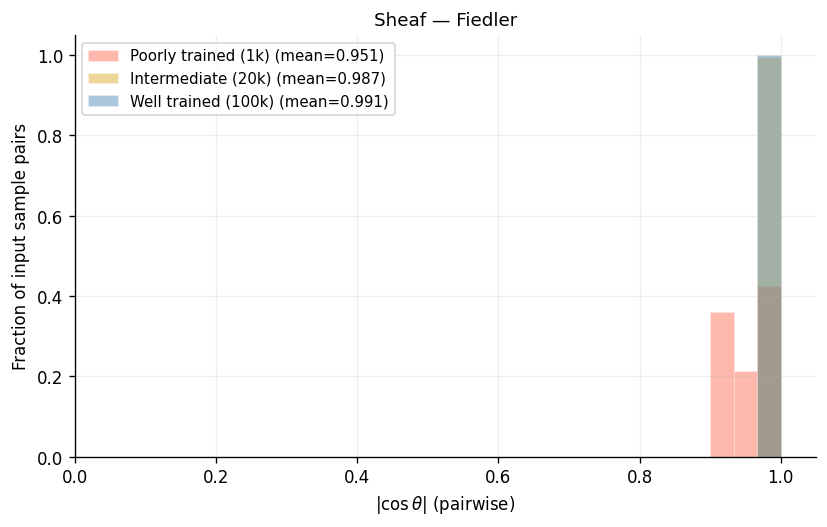

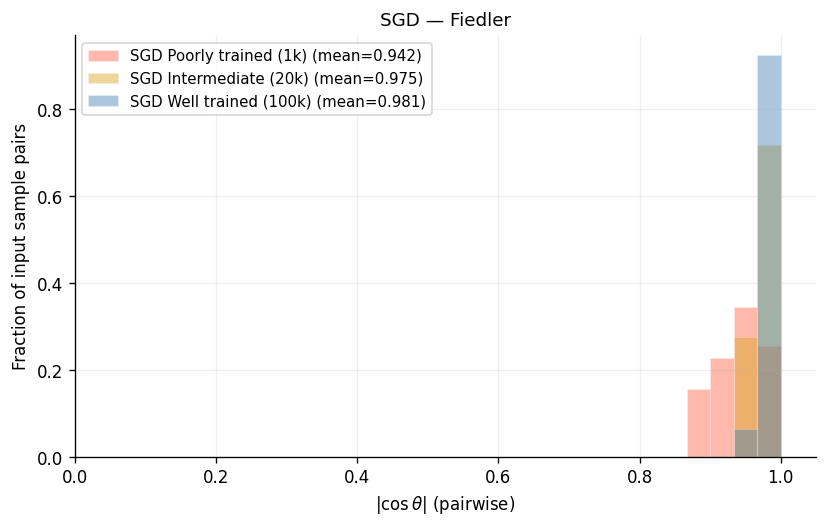

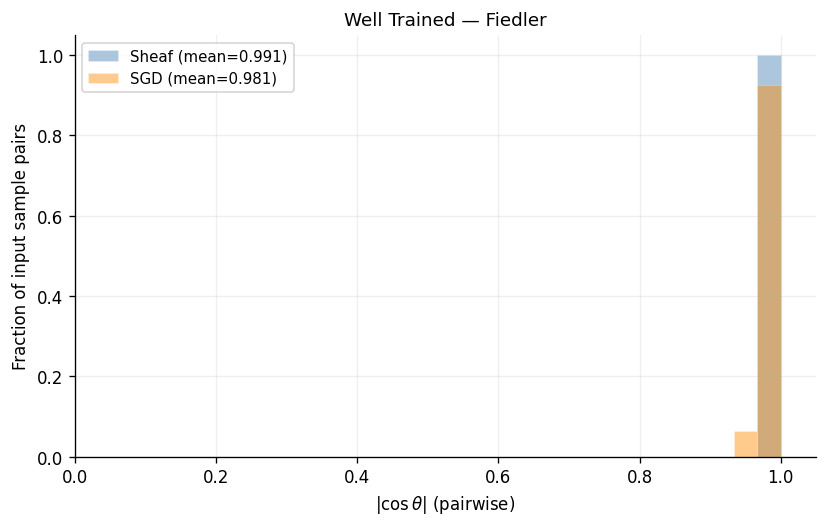

In [13]:
# Fiedler stability
fig = plot_stability_overlay(
    [sheaf_analyses[t]['fiedler_stability']['pairwise_cosines'] for t in tags],
    level_labels, level_colors, eigvec_label='Fiedler', title='Sheaf')
plt.show()

fig = plot_stability_overlay(
    [sgd_analyses[t]['fiedler_stability']['pairwise_cosines'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors,
    eigvec_label='Fiedler', title='SGD')
plt.show()

fig = plot_stability_overlay(
    [sheaf_analyses[best_tag]['fiedler_stability']['pairwise_cosines'],
     sgd_analyses[best_tag]['fiedler_stability']['pairwise_cosines']],
    ['Sheaf', 'SGD'], ['steelblue', 'darkorange'],
    eigvec_label='Fiedler', title='Well Trained')
plt.show()

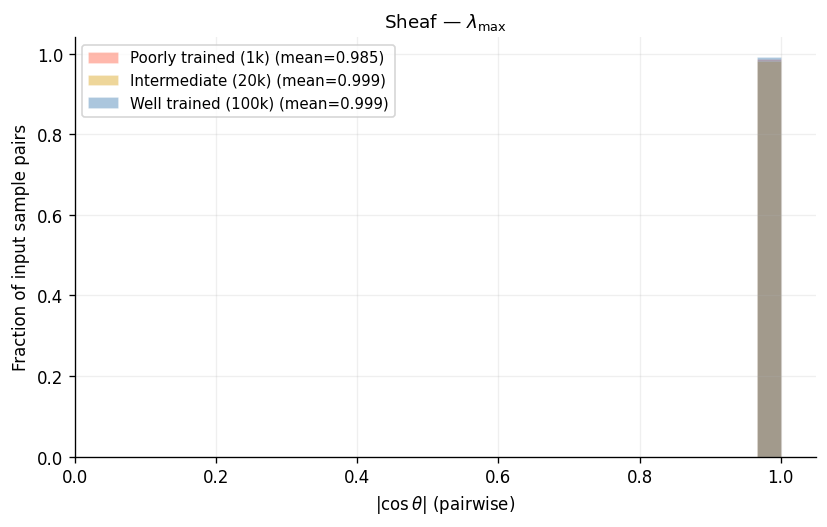

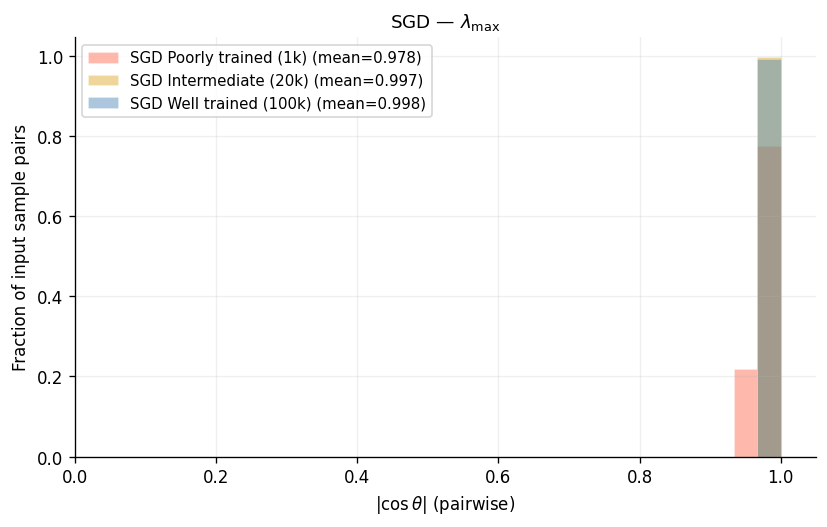

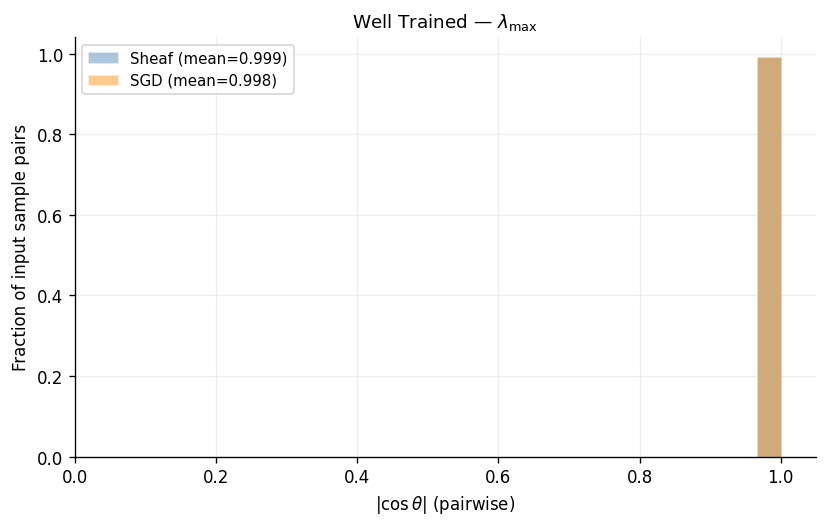

In [14]:
# λ_max stability
fig = plot_stability_overlay(
    [sheaf_analyses[t]['max_stability']['pairwise_cosines'] for t in tags],
    level_labels, level_colors,
    eigvec_label=r'$\lambda_{\max}$', title='Sheaf')
plt.show()

fig = plot_stability_overlay(
    [sgd_analyses[t]['max_stability']['pairwise_cosines'] for t in tags],
    [f"SGD {l}" for l in level_labels], level_colors,
    eigvec_label=r'$\lambda_{\max}$', title='SGD')
plt.show()

fig = plot_stability_overlay(
    [sheaf_analyses[best_tag]['max_stability']['pairwise_cosines'],
     sgd_analyses[best_tag]['max_stability']['pairwise_cosines']],
    ['Sheaf', 'SGD'], ['steelblue', 'darkorange'],
    eigvec_label=r'$\lambda_{\max}$', title='Well Trained')
plt.show()

---
## 5. Spectral Evolution During Training

Tracking the spectral gap, $\lambda_{\max}$, and condition number throughout
the training process.

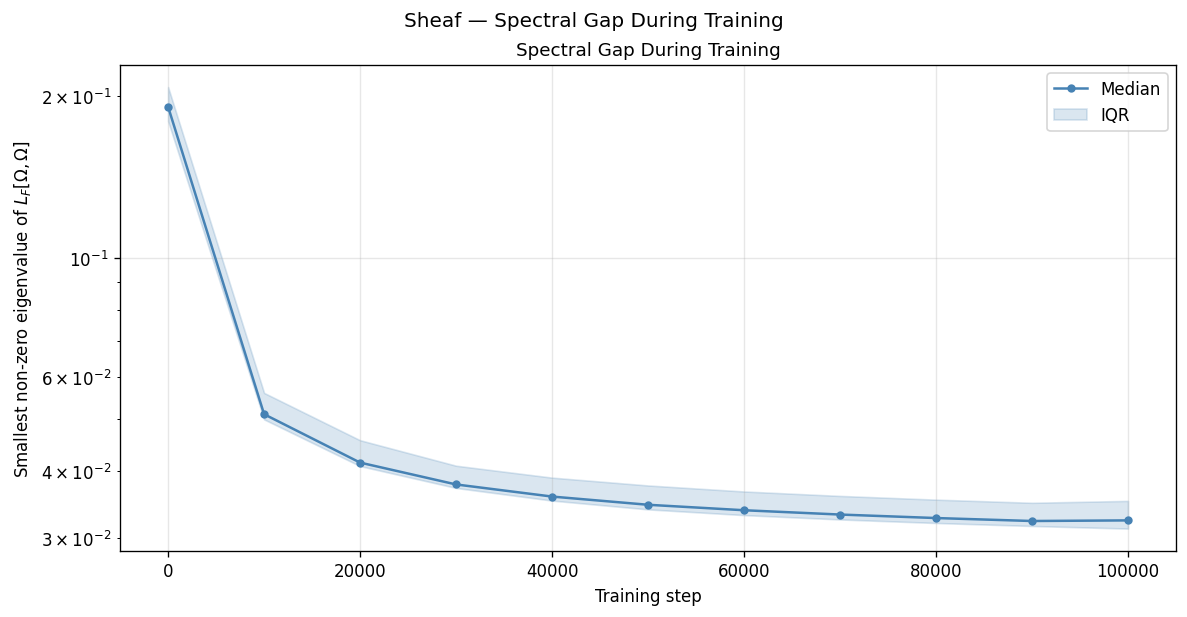

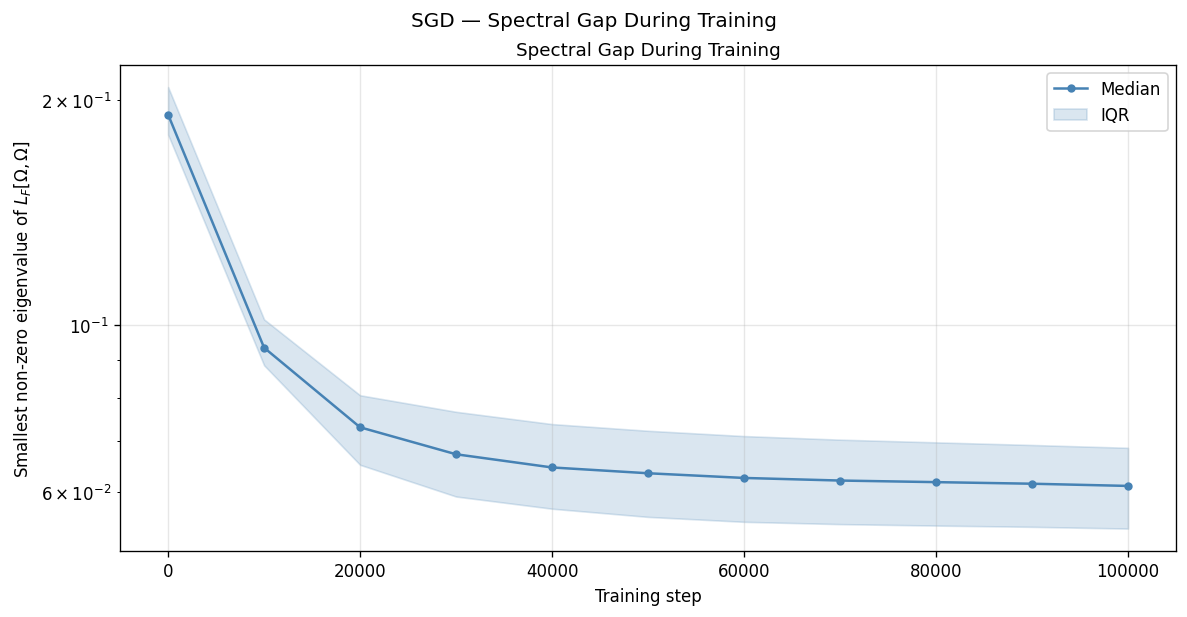

In [15]:
fig_gap_sheaf = plot_spectral_gap_training(sheaf_history)
fig_gap_sheaf.suptitle('Sheaf — Spectral Gap During Training', y=1.02)
plt.show()

fig_gap_sgd = plot_spectral_gap_training(sgd_history)
fig_gap_sgd.suptitle('SGD — Spectral Gap During Training', y=1.02)
plt.show()

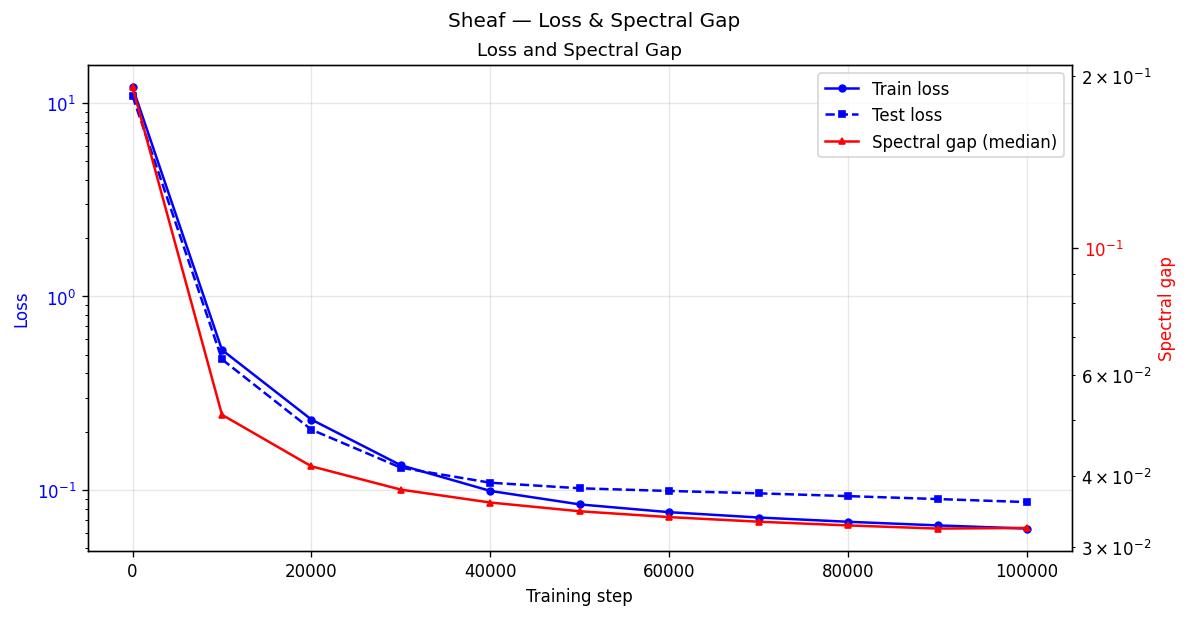

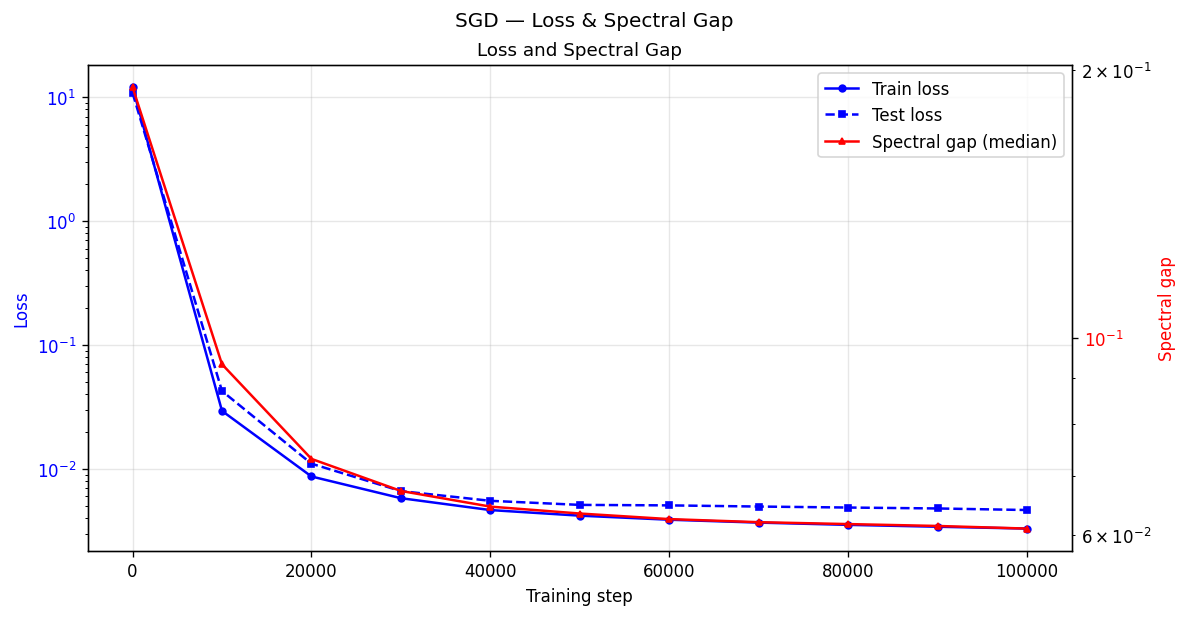

In [16]:
fig_dual_sheaf = plot_loss_spectral_dual(sheaf_history)
fig_dual_sheaf.suptitle('Sheaf — Loss & Spectral Gap', y=1.02)
plt.show()

fig_dual_sgd = plot_loss_spectral_dual(sgd_history)
fig_dual_sgd.suptitle('SGD — Loss & Spectral Gap', y=1.02)
plt.show()

### Extended Spectral Tracking

Full tracking: $\lambda_1$ (gap), $\lambda_{\max}$, and condition number
with interquartile ranges.

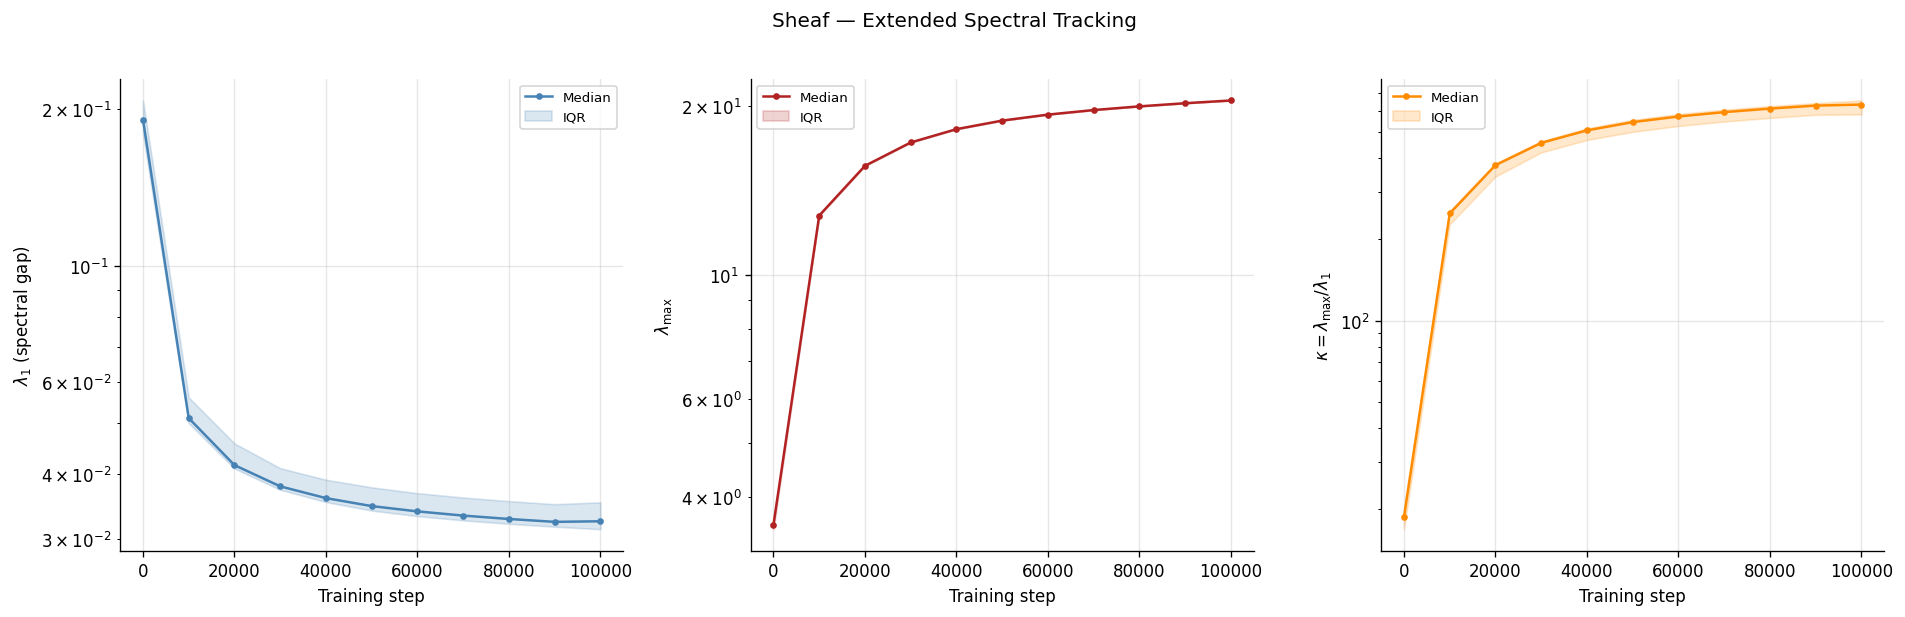

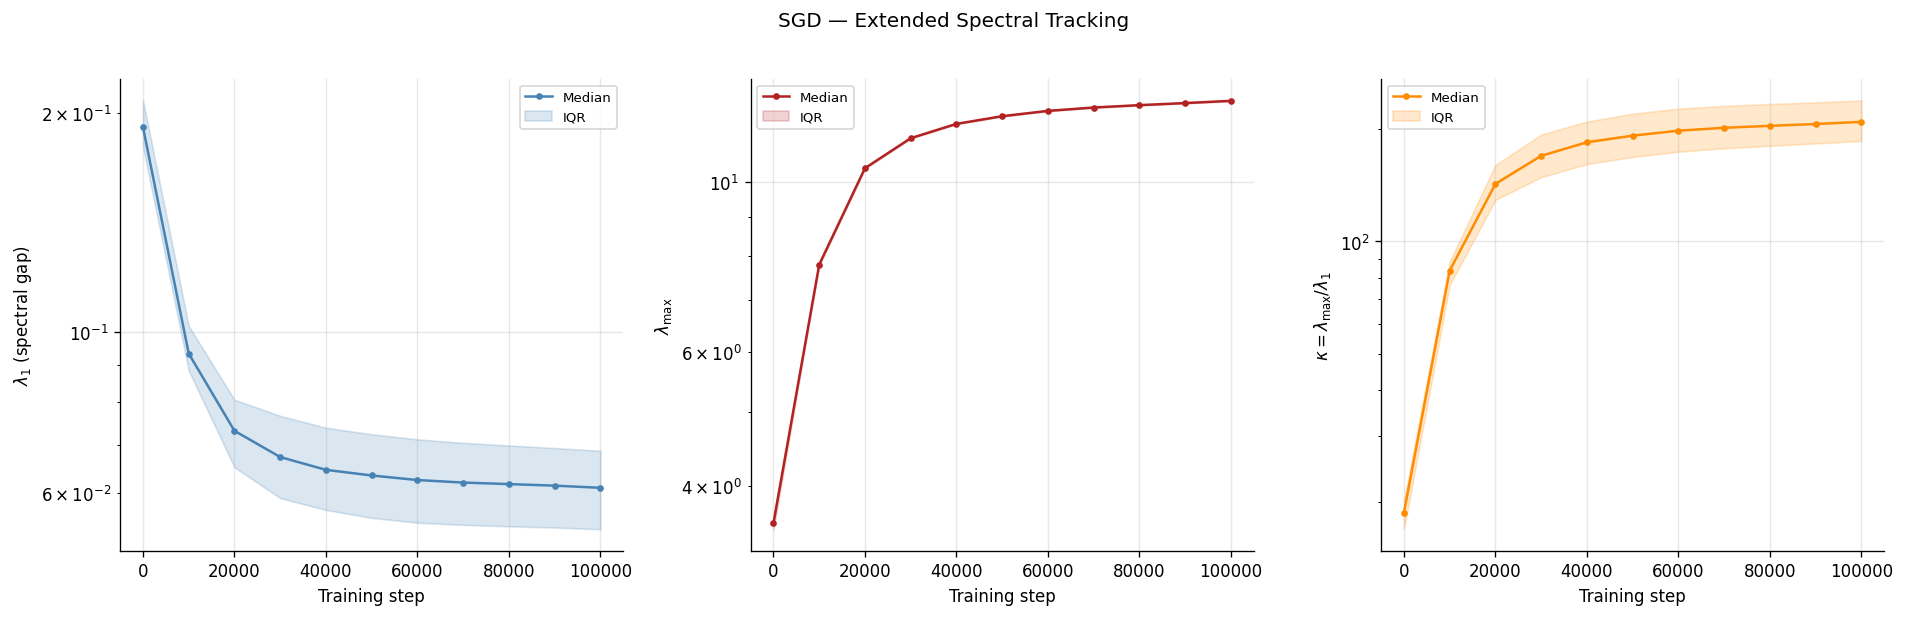

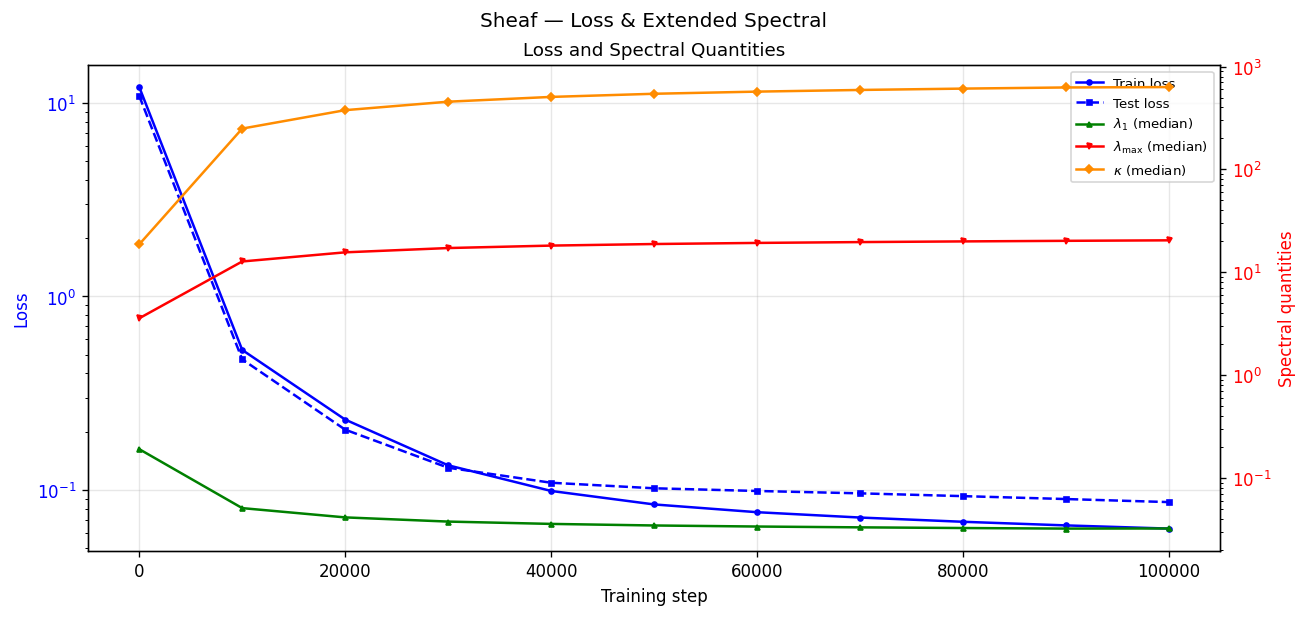

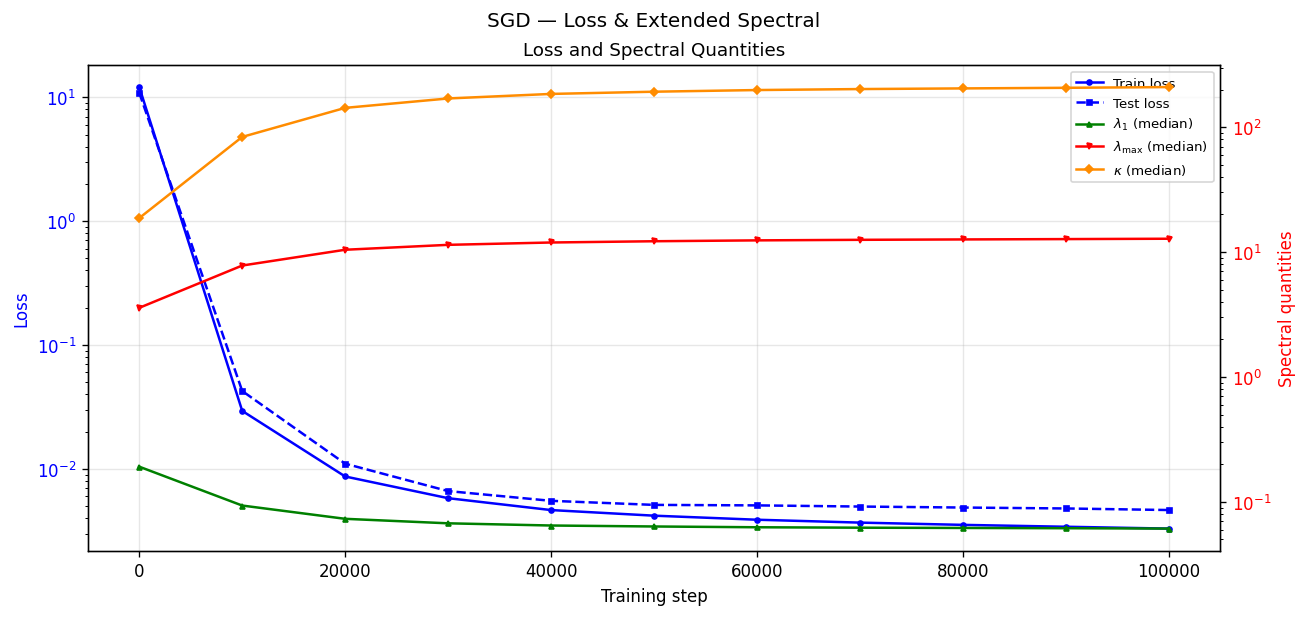

In [17]:
fig_ext_sheaf = plot_spectral_tracking_extended(sheaf_history)
fig_ext_sheaf.suptitle('Sheaf — Extended Spectral Tracking', y=1.02)
plt.show()

fig_ext_sgd = plot_spectral_tracking_extended(sgd_history)
fig_ext_sgd.suptitle('SGD — Extended Spectral Tracking', y=1.02)
plt.show()

fig_ext_dual_sheaf = plot_loss_spectral_dual_extended(sheaf_history)
fig_ext_dual_sheaf.suptitle('Sheaf — Loss & Extended Spectral', y=1.02)
plt.show()

fig_ext_dual_sgd = plot_loss_spectral_dual_extended(sgd_history)
fig_ext_dual_sgd.suptitle('SGD — Loss & Extended Spectral', y=1.02)
plt.show()

---
## Summary

| Analysis | Key Observation |
|----------|----------------|
| **Spectral gap** | $\lambda_1$ stabilises early while loss continues to decrease — the diffusion geometry is set early in training. |
| **Condition number** | $\kappa$ is moderate and stable for well-trained models; high $\kappa$ signals uneven mode structure. |
| **Fiedler energy** | Concentrates on the pre-activation stalk of the widest layer — the information-flow bottleneck. |
| **Eigenvector stability** | High $|\cos\theta|$ for well-trained models: spectral structure is largely input-independent. |
| **Sheaf vs SGD** | Similar spectral structure at similar loss levels — the spectra depend on the weights (restriction maps), not the training algorithm. |

**Next:** Notebook 3b explores discord analysis — per-edge discrepancy
diagnostics that reveal where prediction error concentrates in the network.